In [5]:
import pandas as pd

dataset = pd.read_csv("mental_health_dataset.csv", low_memory=False)

In [6]:
dataset.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [7]:
dataset = dataset.drop(
    columns=['Timestamp', 'self_employed'],errors='ignore')

In [8]:
dataset.head()

,Gender,Country,Occupation,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,Female,United States,Corporate,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,Female,United States,Corporate,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,Female,United States,Corporate,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,Female,United States,Corporate,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,Female,United States,Corporate,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [9]:
X = dataset.drop('Growing_Stress', axis=1)
y = dataset['Growing_Stress']

In [14]:
mask = y.notna()
X = X[mask]
y = y[mask]

In [15]:
y = y.replace({'Yes': 1, 'No': 0, 'Maybe': 2})

In [17]:
X = X.fillna("Unknown")

In [18]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced')

rf.fit(X_train, y_train)



RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [21]:
# Using the model's score method
accuracy = rf.score(X_test, y_test)
print(f"Accuracy on test set: {accuracy:.2f}")

from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on test set: {accuracy:.2f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Classification Report (includes precision, recall, F1-score)
cr = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(cr)

Accuracy on test set: 0.99
Accuracy on test set: 0.99
Confusion Matrix:
[[14170    41     0]
 [  151 15499   122]
 [    0   117 15812]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     14211
         1.0       0.99      0.98      0.99     15772
         2.0       0.99      0.99      0.99     15929

    accuracy                           0.99     45912
   macro avg       0.99      0.99      0.99     45912
weighted avg       0.99      0.99      0.99     45912



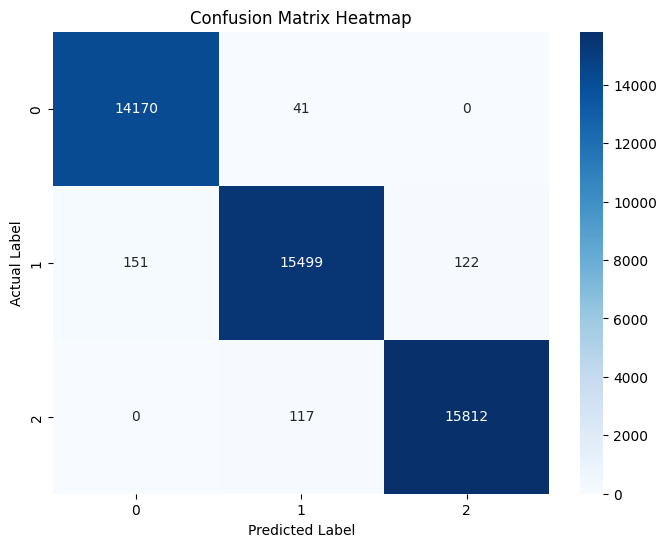

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [7]:
import pandas as pd

dataset = pd.read_csv("mental_health_dataset.csv")
dataset.head(3)

C:\Users\gaura\AppData\Local\Temp\ipykernel_26204\2696229794.py:3: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv("mental_health_dataset.csv")


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [49]:
dataset["Changes_Habits"].unique()

array(['No', 'Yes', 'Maybe', nan], dtype=object)

In [ ]:
dataset["Country"].unique()

array(['United States', 'Poland', 'Australia', 'Canada', 'United Kingdom',
       'South Africa', 'Sweden', 'New Zealand', 'Netherlands', 'India',
       'Belgium', 'Ireland', 'France', 'Portugal', 'Brazil', 'Costa Rica',
       'Russia', 'Germany', 'Switzerland', 'Finland', 'Israel', 'Italy',
       'Bosnia and Herzegovina', 'Singapore', 'Nigeria', 'Croatia',
       'Thailand', 'Denmark', 'Mexico', 'Greece', 'Moldova', 'Colombia',
       'Georgia', 'Czech Republic', 'Philippines', nan], dtype=object)

In [ ]:
dataset["Occupation"].unique()

array(['Corporate', 'Student', 'Business', 'Housewife', 'Others', nan],
      dtype=object)

In [ ]:
dataset["family_history"].unique()

array(['No', 'Yes', nan], dtype=object)

In [ ]:
dataset["treatment"].unique()

array(['Yes', 'No', nan], dtype=object)

In [ ]:
dataset["Days_Indoors"].unique()

array(['1-14 days', 'Go out Every day', 'More than 2 months',
       '15-30 days', '31-60 days', nan], dtype=object)

In [ ]:
dataset["Growing_Stress"].unique()

array(['Yes', 'No', 'Maybe', nan], dtype=object)

In [ ]:
dataset["Changes_Habits"].unique()

array(['No', 'Yes', 'Maybe', nan], dtype=object)

In [ ]:
dataset["Mental_Health_History"].unique()

array(['Yes', 'No', 'Maybe', nan], dtype=object)

In [ ]:
dataset["Mood_Swings"].unique()

array(['Medium', 'Low', 'High', nan], dtype=object)

In [ ]:
dataset["Coping_Struggles"].unique()

array(['No', 'Yes', nan], dtype=object)

In [ ]:
dataset["Work_Interest"].unique()

array(['No', 'Maybe', 'Yes', nan], dtype=object)

In [ ]:
dataset["Social_Weakness"].unique()

array(['Yes', 'No', 'Maybe', nan], dtype=object)

In [ ]:
dataset["mental_health_interview"].unique()

array(['No', 'Maybe', 'Yes', nan], dtype=object)

In [ ]:
dataset["care_options"].unique()

array(['Not sure', 'No', 'Yes', nan], dtype=object)

In [ ]:
import pandas as pd

dataset = pd.read_csv("mental_health_dataset.csv")

X = dataset.drop("Growing_Stress", axis=1)
y = dataset["Growing_Stress"]

mask = y.notna()
X = X[mask]
y = y[mask]


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import joblib

# Encode target
y = y.replace({'Yes': 1, 'No': 0, 'Maybe': 2})

# Handle missing values
X = X.fillna("Unknown")

# One-hot encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Train model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

# Save model
import joblib

import joblib

joblib.dump((rf, X_encoded.columns.tolist()), "mental_stress_model.pkl")

print("Model saved successfully!")



C:\Users\gaura\AppData\Local\Temp\ipykernel_26204\3945777904.py:3: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv("mental_health_dataset.csv")
C:\Users\gaura\AppData\Local\Temp\ipykernel_26204\3945777904.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({'Yes': 1, 'No': 0, 'Maybe': 2})


Model saved successfully!
